In [1]:
import geopandas as gpd
from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

In [2]:
df_matched = gpd.read_file("./df_matched.gpkg")

In [3]:
Y = df_matched["temp"]
T = df_matched["type"]
X = df_matched.drop(columns=["geometry", "pair_id", "type", "temp"])

In [4]:
causal_forest = CausalForestDML(
    model_y=RandomForestRegressor(n_estimators=100, max_depth=5),
    model_t=RandomForestClassifier(n_estimators=100, max_depth=5),
    discrete_treatment=True,
    n_estimators=200,
    random_state=42,
)
causal_forest.fit(Y, T, X=X)

In [16]:
causal_forest.const_marginal_effect()

AssertionError: X was not None when fitting, so can't be none for score or effect

In [5]:
df_matched = df_matched.assign(cooling_effect=causal_forest.effect(X))

<Axes: >

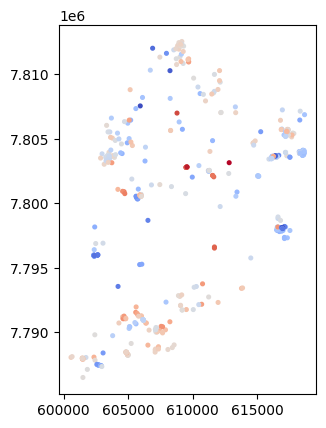

In [6]:
df_matched.plot(column="cooling_effect", s=7, cmap="coolwarm_r")

In [7]:
for feature, imp in zip(X.columns, causal_forest.feature_importances_):
    print(f"{feature}: {imp:.4f}")

elevation: 0.2576
slope: 0.0512
lights: 0.2836
landuse_vacant_lot: 0.0892
landuse_mixed_use: 0.1118
landuse_non_residential: 0.0176
landuse_park: 0.0810
landuse_residential: 0.1080


In [ ]:
lower_bound, upper_bound = causal_forest.effect_interval(X, alpha=0.05)

df_matched = df_matched.assign(cooling_lower=lower_bound, cooling_upper=upper_bound)

significant_warming = df_matched.loc[lambda df: df["cooling_lower"] > 0]
significant_cooling = df_matched.loc[lambda df: df["cooling_upper"] < 0]

print(
    f"Number of points with warming: {len(df_matched.loc[lambda df:  df['cooling_effect'] > 0])} | Significant: {len(significant_warming)}"
)
print(
    f"Number of points with cooling: {len(df_matched.loc[lambda df: df['cooling_effect'] < 0])} | Significant: {len(significant_cooling)}"
)

Number of points with warming: 23 | Significant: 0
Number of points with cooling: 445 | Significant: 257


<Axes: >

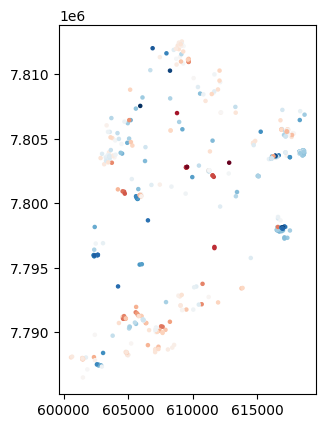

In [14]:
df_matched.plot(column="cooling_effect", cmap="RdBu", s=5)

<Axes: ylabel='Frequency'>

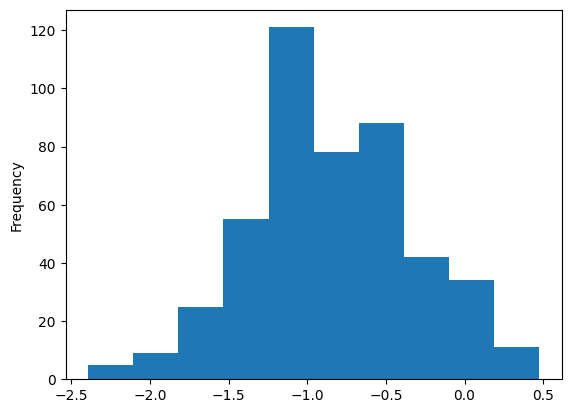

In [10]:
df_matched["cooling_effect"].plot.hist()

In [10]:
best_locations = significant_cooling.sort_values(by="cooling_effect")

<Axes: >

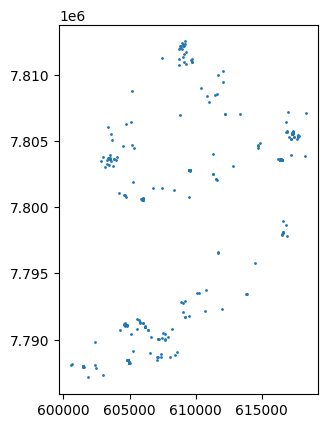

In [11]:
best_locations.plot(markersize=1)